### Data Loading

In [1]:
%load_ext autoreload
%autoreload 2
import warnings, os
warnings.simplefilter(action='ignore')

from src.costream.data import group_files_by_subject
from src.costream.evaluation import run_experiment, run_subject_cv, train_models, evaluate_models
import numpy as np
from src.fall_lm import FallLM
from src.models import get_model_specs
from src import utils

FALL_DIR = "data/farseeing/fall"
FREQ = 100
WINDOW_SEC = 3

In [2]:
# Data loading based on metadata
import pandas as pd 

data_desc = pd.read_excel("data/farseeing/description.xlsx", engine='openpyxl',
                          usecols=['Randomnumber', 'Sensor_location', 'Sample_rate_Hz'])
l5 = data_desc[data_desc['Sensor_location'] == 'L5']
l5 = l5[l5['Sample_rate_Hz'] == FREQ]
l5_subjects = set(l5['Randomnumber'].str.split('-').str[0])
l5[l5['Sample_rate_Hz'] != FREQ]
len(l5_subjects)

54

In [3]:
# Subject-wise train/test split
from sklearn.model_selection import train_test_split

# Group files
fall_subject_map = group_files_by_subject(FALL_DIR, id_extractor=utils.fall_id_extractor)
# Limit fall subjects to subjects with 'L5' data only
fall_subject_map = {s: fps for s, fps in fall_subject_map.items() if s in l5_subjects}
fall_subjects = list(fall_subject_map.keys())
print(f"Found {len(fall_subjects)} fall subjects: {fall_subjects[:3]} ...")

# Split Subjects into Train / Test
train_subjs_fall, test_subjs_fall = train_test_split(fall_subjects, test_size=0.2, random_state=42)
# For each subject 's', get every file 'f' in fall_subject_map[s]
train_files_fall = [f for s in train_subjs_fall for f in fall_subject_map[s]]
test_files_fall  = [f for s in test_subjs_fall  for f in fall_subject_map[s]]
# Now load them
train_dfs_fall = utils.load_fall_subject(train_files_fall)
test_dfs_fall  = utils.load_fall_subject(test_files_fall)

Found 40 fall subjects: ['93807530', '79336438', '18194920'] ...


### Cross-validation Experiment

In [4]:
# Load the subject data into memory for quick access during modeling
# This is a dict of {subject_id: [list of dataframes for that subject's files]}
subject_df_map = {s: utils.load_fall_subject(fall_subject_map[s]) for s in fall_subject_map.keys()}

In [ ]:
# Run five-fold cross-validation
warnings.filterwarnings("ignore")
os.makedirs('output/results', exist_ok=True)

model_specs = get_model_specs(random_state=42)

cv_results_df = []
print("Running cross-validation experiments...")
cv_res = run_subject_cv(
    subject_map=subject_df_map,
    model_specs=model_specs,
    feature_cols=['mag'],
    window_size=WINDOW_SEC,
    cv=5,
    step=1.0,
    spacing="multiphase",
    verbose=True,
    use_post_event_data=False, 
    tolerance=[3,20]
)
display(cv_res)
cv_res.to_csv('output/results/cv_results.csv', index=False)

Running cross-validation experiments...

=== Fold 1/5 | Train Subjects: 32 | Test Subjects: 8 ===
  Segmented Train Data: (1627, 300)


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
Epoch 21: Train 0.0003 | Val 0.0262:  22%|██▏       | 22/100 [00:56<03:21,  2.58s/it]



=== Fold 2/5 | Train Subjects: 32 | Test Subjects: 8 ===
  Segmented Train Data: (2563, 300)


Epoch 15: Train 0.0007 | Val 0.0298:  16%|█▌        | 16/100 [01:07<05:52,  4.19s/it]



=== Fold 3/5 | Train Subjects: 32 | Test Subjects: 8 ===
  Segmented Train Data: (2380, 300)


...


=== Fold 4/5 | Train Subjects: 32 | Test Subjects: 8 ===
  Segmented Train Data: (2647, 300)


Epoch 19: Train 0.0013 | Val 0.0096:  20%|██        | 20/100 [01:25<05:40,  4.25s/it]



=== Fold 5/5 | Train Subjects: 32 | Test Subjects: 8 ===
  Segmented Train Data: (2755, 300)


Epoch 24: Train 0.0001 | Val 0.0161:  25%|██▌       | 25/100 [01:49<05:27,  4.37s/it]


,model,tp,fp,tn,fn,runtime,delay,precision,recall,specificity,f1-score,auc,false alarm rate,miss rate,gain,thresh,fold
0,WEASEL,29,11,36584,7,9.106846,-1.649062,0.725000,0.805556,0.999699,0.763158,0.902627,0.107819,0.068612,-0.245044,0.5,1
1,MrSQM,26,10,36585,10,7.585224,-0.296406,0.722222,0.722222,0.999727,0.722222,0.860974,0.098018,0.098018,-0.294053,0.5,1
2,Quant,29,11,36584,7,0.355491,-1.149062,0.725000,0.805556,0.999699,0.763158,0.902627,0.107819,0.068612,-0.245044,0.5,1
3,MiniRocket,32,12,36583,4,0.522483,-1.392344,0.727273,0.888889,0.999672,0.800000,0.944280,0.117621,0.039207,-0.196035,0.5,1
4,Mantis,32,11,36584,4,1.205414,-1.517344,0.744186,0.888889,0.999699,0.810127,0.944294,0.107819,0.039207,-0.186233,0.5,1
5,FallLM,32,54,36541,4,0.015543,-2.195937,0.372093,0.888889,0.998524,0.524590,0.943707,0.529295,0.039207,-0.588106,0.5,1
6,WEASEL,29,3,42029,11,2.951143,-1.130833,0.906250,0.725000,0.999929,0.805556,0.862464,0.025603,0.093877,-0.213357,0.5,2
7,MrSQM,26,12,42020,14,2.449836,-0.672500,0.684211,0.650000,0.999715,0.666667,0.824857,0.102411,0.119480,-0.341371,0.5,2
8,Quant,32,3,42029,8,0.229092,-0.866944,0.914286,0.800000,0.999929,0.853333,0.899964,0.025603,0.068274,-0.162151,0.5,2
9,MiniRocket,28,4,42028,12,0.170636,-0.805556,0.875000,0.700000,0.999905,0.777778,0.849952,0.034137,0.102411,-0.238960,0.5,2


In [6]:
# Aggregate CV results by model and display sorted by F1-score
from src.costream.evaluation import aggregate_cv_results

cv_res = pd.read_csv('output/results/cv_results.csv')
agg_res = aggregate_cv_results(cv_res, exclude_cols=['tp', 'fp', 'tn', 'fn',
                                                      'thresh', 'gain', 'specificity'])
agg_res.to_csv('output/results/cv_results_agg.csv', index=False)
display(agg_res.sort_values('f1-score', ascending=False))

,model,runtime,delay,precision,recall,f1-score,auc,false alarm rate,miss rate
1,Mantis,0.84 ± 0.33,-1.28 ± 0.22,0.78 ± 0.05,0.89 ± 0.07,0.83 ± 0.02,0.94 ± 0.03,0.08 ± 0.03,0.04 ± 0.02
4,Quant,0.27 ± 0.06,-0.88 ± 0.15,0.84 ± 0.08,0.8 ± 0.01,0.82 ± 0.04,0.9 ± 0.0,0.05 ± 0.03,0.06 ± 0.0
5,WEASEL,4.77 ± 2.94,-1.23 ± 0.25,0.82 ± 0.08,0.8 ± 0.05,0.81 ± 0.03,0.9 ± 0.02,0.06 ± 0.04,0.06 ± 0.02
2,MiniRocket,0.27 ± 0.18,-1.12 ± 0.22,0.8 ± 0.06,0.82 ± 0.08,0.8 ± 0.03,0.91 ± 0.04,0.07 ± 0.03,0.06 ± 0.03
3,MrSQM,3.9 ± 2.49,-0.51 ± 0.25,0.64 ± 0.09,0.68 ± 0.04,0.66 ± 0.05,0.84 ± 0.02,0.13 ± 0.05,0.1 ± 0.01
0,FallLM,0.01 ± 0.0,-2.31 ± 0.2,0.52 ± 0.11,0.87 ± 0.1,0.64 ± 0.09,0.93 ± 0.05,0.28 ± 0.15,0.04 ± 0.03


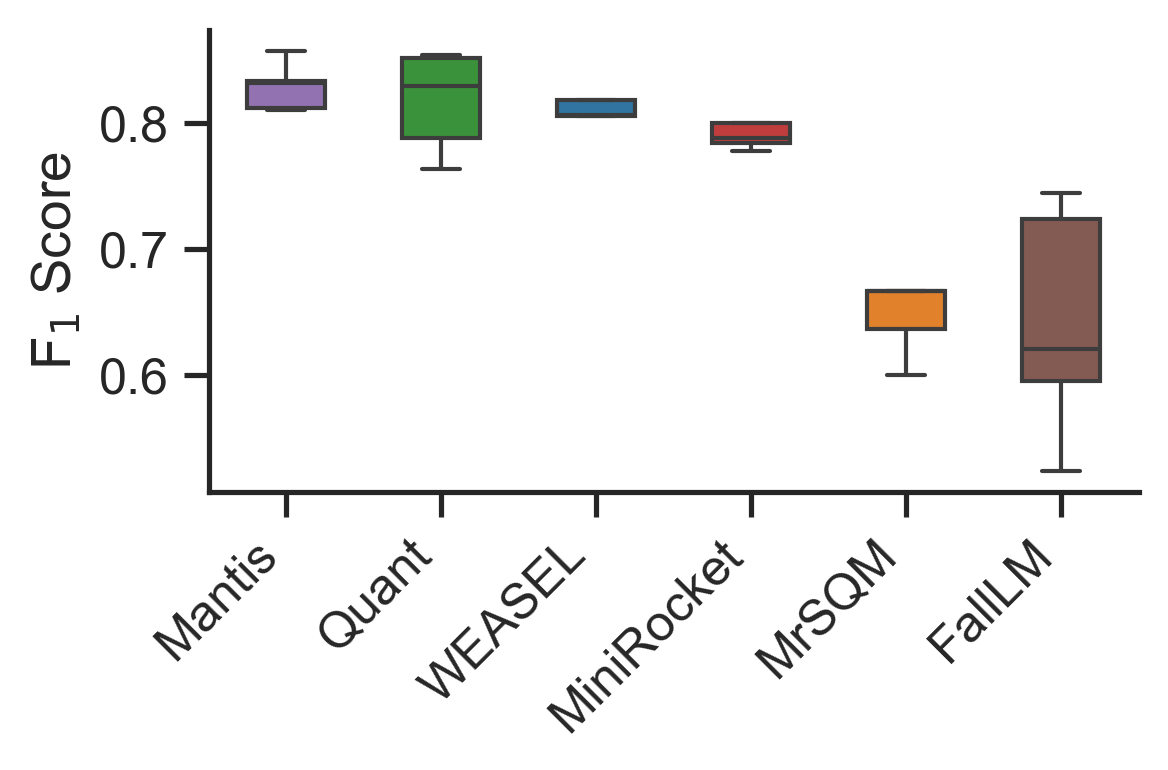

In [7]:
from costream.evaluation import metric_box
import matplotlib.pyplot as plt

os.makedirs("output/figures", exist_ok=True)
model_order_by_f1 = agg_res.sort_values('f1-score', ascending=False)['model'].tolist()
fig, ax = plt.subplots(1,1, figsize=(4,2), dpi=300)
metric_box(cv_res, metric='f1-score', x='model', order=model_order_by_f1, ax=ax)
ax.set_title("")
ax.set_ylabel(r"F$_1$ Score")
# save figure
fig.savefig("output/figures/f1_score_boxplot.pdf", dpi=300, bbox_inches='tight')

### Fall Scarcity Experiment

In [5]:
# Segment and save
win_sec = 3
os.makedirs("data/preprocessed", exist_ok=True)
    
# 2D magnitude signal
X_train, y_train, test_signals, test_events = utils.segment_and_save(
    train_dfs_fall,
    test_dfs_fall,
    feat_cols=["mag"], 
    win_sec=win_sec, 
    thresh=1.4, 
    suffix=""
)

WIN_SEC=3:
  Train: X=(1924, 300), y=(1924,), balance=[1812  112] (0=ADL, 1=Fall)
  Test:  34 signals, 34 event lists


In [9]:
# 5-fold subject-wise partition of FARSEEING fall subjects (full coverage, no overlap)
from sklearn.model_selection import KFold

kf = KFold(n_splits=5, shuffle=True, random_state=42)
farseeing_test_splits = []
for fold_idx, (_, test_idx) in enumerate(kf.split(fall_subjects)):
    test_subjs = [fall_subjects[i] for i in test_idx]
    test_files = [f for s in test_subjs for f in fall_subject_map[s]]
    fold_test_dfs = utils.load_fall_subject(test_files)
    fold_signals, fold_events = utils.extract_test_signals_events(fold_test_dfs, feat_cols=["mag"])
    farseeing_test_splits.append((fold_signals, fold_events))
    print(f"Fold {fold_idx}: {len(test_subjs)} subjects -> {len(fold_signals)} recordings")

Fold 0: 8 subjects -> 34 recordings
Fold 1: 8 subjects -> 34 recordings
Fold 2: 8 subjects -> 29 recordings
Fold 3: 8 subjects -> 24 recordings
Fold 4: 8 subjects -> 26 recordings


In [ ]:
# Fractions of FALL EVENTS to keep
fractions = [0.01, 0.05, 0.10, 0.25, 0.50, 1.0]

# Multiple seeds for robustness
seeds = [0, 1, 2, 3, 4]

# Identify fall and ADL indices ONCE
fall_indices = np.where(y_train == 1)[0]
adl_indices  = np.where(y_train == 0)[0]

SCARCITY_CSV = 'output/results/scarcity_results.csv'
if os.path.exists(SCARCITY_CSV):
    prev_scarcity_df = pd.read_csv(SCARCITY_CSV)
    prev_non_fallm_df = prev_scarcity_df[prev_scarcity_df['model'] != 'FallLM'].copy()
    rerun_models = "FallLM"
else:
    prev_non_fallm_df = None
    rerun_models = None

all_results = []

for frac in fractions:
    for seed in seeds:
        rng = np.random.default_rng(seed)
        if frac < 1.0:
            n_keep = max(1, int(np.ceil(frac * len(fall_indices))))
            selected_falls = rng.choice(fall_indices, size=n_keep, replace=False)
            keep_indices = np.concatenate([selected_falls, adl_indices])
        else:
            n_keep = len(fall_indices)
            keep_indices = np.arange(len(y_train))
        # Shuffle to avoid any ordering bias in training data
        rng.shuffle(keep_indices)
        # Subset training data
        X_sub = X_train[keep_indices]
        y_sub = y_train[keep_indices]
        # Define models exactly as before (optionally restricted to FallLM only)
        scarc_specs = get_model_specs(random_state=seed, include=rerun_models)
        # Run experiment
        res = run_experiment(
            X_train=X_sub,
            y_train=y_sub,
            test_signals=test_signals,
            test_event_points=test_events,
            model_specs=scarc_specs,
            window_size=3.0,
            step=1.0,
            freq=100,
            signal_thresh=1.4,
            tolerance=[3,20],
            debounce_secs=60,
            verbose=False,
            random_state=seed
        )
        res['train_fraction'] = frac
        res['seed'] = seed
        res['n_falls_used'] = n_keep
        res['total_samples_used'] = len(keep_indices)
        all_results.append(res)

new_results_df = pd.concat(all_results, ignore_index=True)

if prev_non_fallm_df is not None:
    final_scarcity_df = pd.concat([prev_non_fallm_df, new_results_df], ignore_index=True)
else:
    final_scarcity_df = new_results_df

final_scarcity_df = final_scarcity_df.sort_values(['train_fraction', 'seed', 'model']).reset_index(drop=True)
final_scarcity_df.to_csv(SCARCITY_CSV, index=False)
print("\nFINAL DATA SCARCITY RESULTS (Multi-Seed)")
display(final_scarcity_df)

Epoch 99: Train 0.0000 | Val 0.0000: 100%|██████████| 100/100 [04:46<00:00,  2.87s/it]
Epoch 99: Train 0.0000 | Val 0.0000: 100%|██████████| 100/100 [04:50<00:00,  2.90s/it]
Epoch 99: Train 0.0000 | Val 0.0000: 100%|██████████| 100/100 [04:47<00:00,  2.87s/it]
Epoch 99: Train 0.0000 | Val 0.0000: 100%|██████████| 100/100 [05:17<00:00,  3.17s/it]
Epoch 37: Train 0.0001 | Val 0.0002:  38%|███▊      | 38/100 [01:53<03:05,  2.99s/it]
Epoch 19: Train 0.0001 | Val 0.0098:  20%|██        | 20/100 [00:59<03:56,  2.96s/it]
Epoch 16: Train 0.0001 | Val 0.0118:  17%|█▋        | 17/100 [00:50<04:07,  2.99s/it]
Epoch 15: Train 0.0002 | Val 0.0104:  16%|█▌        | 16/100 [00:48<04:16,  3.06s/it]
Epoch 31: Train 0.0001 | Val 0.0007:  32%|███▏      | 32/100 [01:32<03:16,  2.90s/it]
Epoch 99: Train 0.0000 | Val 0.0000: 100%|██████████| 100/100 [04:41<00:00,  2.81s/it]
Epoch 17: Train 0.0002 | Val 0.0115:  18%|█▊        | 18/100 [00:54<04:07,  3.01s/it]
Epoch 20: Train 0.0001 | Val 0.0076:  21%|██     


FINAL DATA SCARCITY RESULTS (Multi-Seed)


,model,tp,fp,tn,fn,runtime,delay,precision,recall,specificity,f1-score,auc,false alarm rate,miss rate,gain,thresh,train_fraction,seed,n_falls_used,total_samples_used
0,FallLM,19,14,40173,19,0.011361,-1.480588,0.575758,0.500000,0.999652,0.535211,0.749826,0.124975,0.169609,-0.379388,0.5,0.01,0,2,1814
1,Mantis,7,0,40187,31,0.530361,-0.205882,1.000000,0.184211,1.000000,0.311111,0.592105,0.000000,0.276730,-0.553460,0.5,0.01,0,2,1814
2,MiniRocket,0,0,40187,38,0.359388,0.000000,0.000000,0.000000,1.000000,0.000000,0.500000,0.000000,0.339217,-0.678435,0.5,0.01,0,2,1814
3,MrSQM,0,0,40187,38,4.966540,0.000000,0.000000,0.000000,1.000000,0.000000,0.500000,0.000000,0.339217,-0.678435,0.5,0.01,0,2,1814
4,Quant,2,0,40187,36,0.264534,-0.058824,1.000000,0.052632,1.000000,0.100000,0.526316,0.000000,0.321364,-0.642728,0.5,0.01,0,2,1814
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175,Mantis,35,12,40175,3,0.528377,-1.816765,0.744681,0.921053,0.999701,0.823529,0.960377,0.107121,0.026780,-0.160682,0.5,1.00,4,112,1924
176,MiniRocket,33,7,40180,5,0.454803,-1.552059,0.825000,0.868421,0.999826,0.846154,0.934123,0.062487,0.044634,-0.151755,0.5,1.00,4,112,1924
177,MrSQM,31,10,40177,7,4.644042,-0.073088,0.756098,0.815789,0.999751,0.784810,0.907770,0.089268,0.062487,-0.214243,0.5,1.00,4,112,1924
178,Quant,32,5,40182,6,0.274727,-1.169706,0.864865,0.842105,0.999876,0.853333,0.920990,0.044634,0.053561,-0.151755,0.5,1.00,4,112,1924


In [11]:
# Compute fall ratio percentage
final_scarcity_df['fall_ratio_pct'] = (final_scarcity_df['n_falls_used'] / final_scarcity_df['total_samples_used']) * 100
summary_df = (
    final_scarcity_df
    .groupby(['model', 'train_fraction', 'fall_ratio_pct', 'total_samples_used'])
    .agg({
        'f1-score': ['mean', 'std'],
        'recall': ['mean', 'std'],
        'precision': ['mean', 'std'],
        'auc': ['mean', 'std'],
        'false alarm rate': ['mean', 'std']
    })
    .reset_index()
)
display(summary_df.sort_values(by=['train_fraction', 'model']))

model train_fraction fall_ratio_pct total_samples_used  f1-score  \
                                                                     mean   
0       FallLM           0.01       0.110254               1814  0.345906   
6       Mantis           0.01       0.110254               1814  0.150027   
12  MiniRocket           0.01       0.110254               1814  0.010256   
18       MrSQM           0.01       0.110254               1814  0.000000   
24       Quant           0.01       0.110254               1814  0.030256   
30      WEASEL           0.01       0.110254               1814  0.000000   
1       FallLM           0.05       0.330033               1818  0.678760   
7       Mantis           0.05       0.330033               1818  0.588446   
13  MiniRocket           0.05       0.330033               1818  0.473434   
19       MrSQM           0.05       0.330033               1818  0.000000   
25       Quant           0.05       0.330033               1818  0.275482   
31      WEASEL           0.05       0.330033               1818  0.165502   
2       FallLM           0.10       0.657895               1824  0.677691   
8       Mantis           0.10       0.657895               1824  0.624374   
14  MiniRocket           0.10       0.657895               1824  0.654337   
20       MrSQM           0.10       0.657895               1824  0.000000   
26       Quant           0.10       0.657895               1824  0.426790   
32      WEASEL           0.10       0.657895               1824  0.543989   
3       FallLM           0.25       1.521739               1840  0.717581   
9       Mantis           0.25       1.521739               1840  0.755130   
15  MiniRocket           0.25       1.521739               1840  0.830240   
21       MrSQM           0.25       1.521739               1840  0.454690   
27       Quant           0.25       1.521739               1840  0.788255   
33      WEASEL           0.25       1.521739               1840  0.830291   
4       FallLM           0.50       2.997859               1868  0.643671   
10      Mantis           0.50       2.997859               1868  0.812586   
16  MiniRocket           0.50       2.997859               1868  0.858615   
22       MrSQM           0.50       2.997859               1868  0.648470   
28       Quant           0.50       2.997859               1868  0.809942   
34      WEASEL           0.50       2.997859               1868  0.877596   
5       FallLM           1.00       5.821206               1924  0.619091   
11      Mantis           1.00       5.821206               1924  0.848869   
17  MiniRocket           1.00       5.821206               1924  0.844644   
23       MrSQM           1.00       5.821206               1924  0.767587   
29       Quant           1.00       5.821206               1924  0.850366   
35      WEASEL           1.00       5.821206               1924  0.883117   

                recall           precision                 auc            \
         std      mean       std      mean       std      mean       std   
0   0.196064  0.421053  0.055824  0.386866  0.363528  0.709770  0.028200   
6   0.110110  0.084211  0.065526  0.800000  0.447214  0.542103  0.032767   
12  0.022934  0.005263  0.011769  0.200000  0.447214  0.502632  0.005884   
18  0.000000  0.000000  0.000000  0.000000  0.000000  0.500000  0.000000   
24  0.044868  0.015789  0.023538  0.400000  0.547723  0.507895  0.011769   
30  0.000000  0.000000  0.000000  0.000000  0.000000  0.500000  0.000000   
1   0.092537  0.715789  0.189218  0.676831  0.113441  0.857721  0.094556   
7   0.061290  0.431579  0.057655  0.930516  0.051668  0.715775  0.028832   
13  0.089142  0.326316  0.088462  0.905275  0.061501  0.663140  0.044224   
19  0.000000  0.000000  0.000000  0.000000  0.000000  0.500000  0.000000   
25  0.168696  0.168421  0.111026  1.000000  0.000000  0.584211  0.055513   
31  0.132884  0.094737  0.078065  0.800000  0.447214  0.547368  0.039033   
2   0.093815  0.82

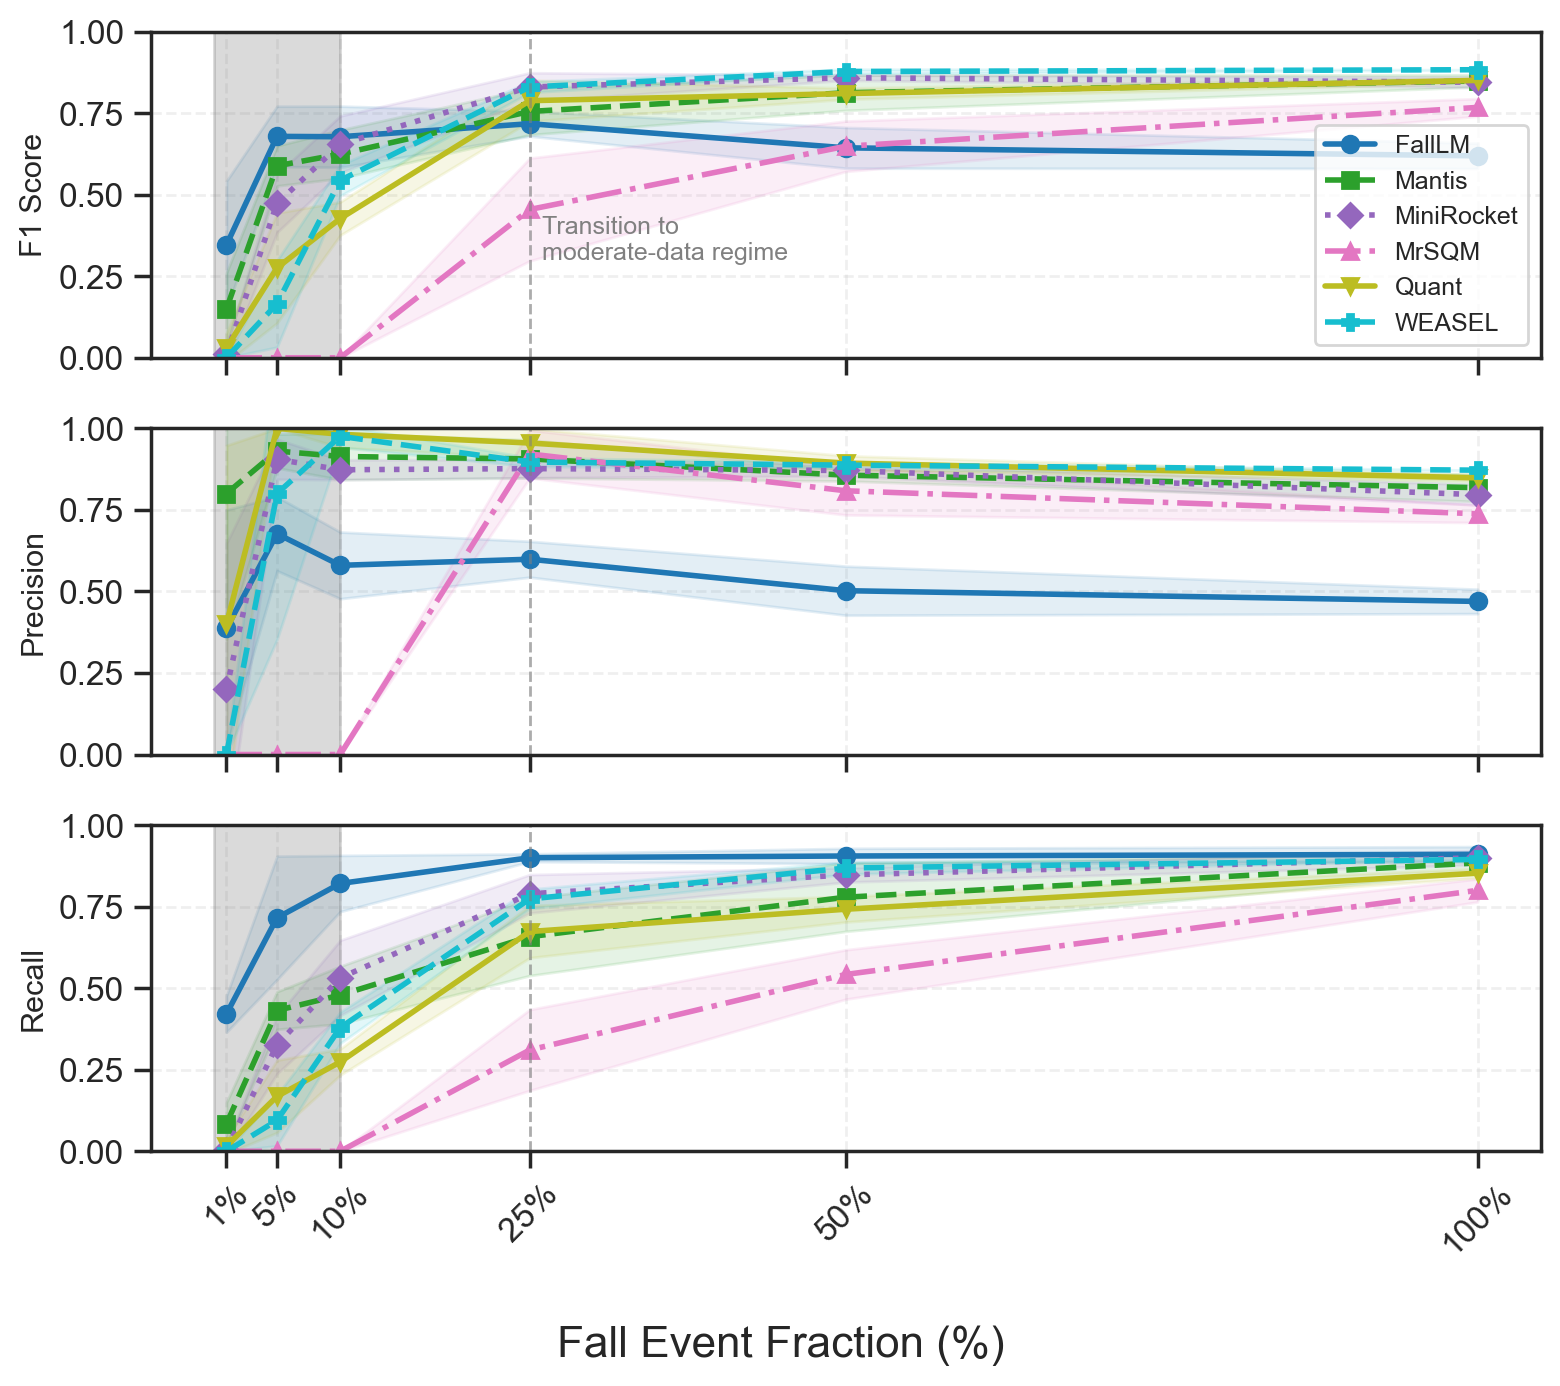

In [12]:
from matplotlib import markers
import matplotlib.pyplot as plt
import numpy as np

summary_df['fall_event_fraction_pct'] = summary_df['train_fraction'] * 100
models = summary_df["model"].unique()
metrics = ['f1-score', 'precision', 'recall']

colors = plt.cm.tab10(np.linspace(0, 1, len(models)))
linestyles = ['-', '--', ':', '-.']
markers = ['o', 's', 'D', '^', 'v', 'P', '*']
fig, axes = plt.subplots(3, 1, figsize=(8, 7), dpi=200, sharex=True)
summary_df_sorted = summary_df.sort_values(['model', 'fall_event_fraction_pct'])

for ax, metric in zip(axes, metrics):
    for idx, model in enumerate(models):
        sub = summary_df_sorted[summary_df_sorted["model"] == model]
        x = sub["fall_event_fraction_pct"].values
        y = sub[metric]["mean"].values
        yerr = sub[metric]["std"].values

        # Highlight extreme scarcity region
        ax.axvspan(0, 10, color='gray', alpha=0.05)
        ax.plot(
            x, y,
            marker=markers[idx % len(markers)],
            linewidth=2,
            label=model,
            color=colors[idx],
            linestyle=linestyles[idx % len(linestyles)],
            markersize=6
        )
        ax.fill_between(x, y - yerr, y + yerr, alpha=0.12, color=colors[idx])
    # Mark regime transition where models converge
    transition_point = 25
    ax.axvline(transition_point, color='gray', linestyle='--', linewidth=1, alpha=0.6)
    ax.set_ylabel(metric.replace('-', ' ').title(), fontsize=11)
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3, linestyle='--')

    if metric == 'f1-score':
        ax.legend(fontsize=9, loc='best')
        ax.text(
            26, 0.3,
            "Transition to\nmoderate-data regime",
            fontsize=9,
            color='gray'
        )

    ax.set_xticks(sorted(summary_df_sorted["fall_event_fraction_pct"].unique()))
    ax.set_xticklabels(
        [f"{x:.0f}%" for x in sorted(summary_df_sorted["fall_event_fraction_pct"].unique())],
        rotation=45
    )

fig.supxlabel('Fall Event Fraction (%)')
plt.tight_layout()
plt.savefig('output/figures/scarcity_analysis.pdf', dpi=300, bbox_inches='tight')
plt.show()

### Cross-dataset generalisation experiments
Train on `FallAllD` (simulated) and test on `FARSEEING` (real-world)

In [13]:
from src.fallalld import load_fallalld, adapter_fallalld_to_costream

fallalld_df = load_fallalld()
fallalld_subject_map = adapter_fallalld_to_costream(fallalld_df)

# Create training data from FallALlD
fallalld_subjects = list(fallalld_subject_map.keys())
fallalld_train_subjects, fallalld_test_subjects = train_test_split(
    fallalld_subjects, test_size=0.2, random_state=42)
fallalld_train_map = {s: fallalld_subject_map[s] for s in fallalld_train_subjects}

Adapting DataFrame to Costream format...


100%|██████████| 1745/1745 [00:00<00:00, 7903.87it/s]


In [14]:
fallalld_train_dfs = []
for s in fallalld_train_subjects:
    fallalld_train_dfs.extend(fallalld_subject_map[s])
fall_alld_test_dfs = []
for s in fallalld_test_subjects:
    fall_alld_test_dfs.extend(fallalld_subject_map[s])

In [15]:
X_train_f, y_train_f, test_signals_f, test_events_f = utils.segment_and_save(
    fallalld_train_dfs, fall_alld_test_dfs,
    feat_cols=['mag'], win_sec=3, thresh=1.4, suffix="fallalld", freq=100, orig_freq=238)

Resampling from 238Hz to 100Hz...
WIN_SEC=3:
  Train: X=(5597, 300), y=(5597,), balance=[5242  355] (0=ADL, 1=Fall)
  Test:  380 signals, 380 event lists


In [16]:
# Train once on FallAllD; evaluate on FallAllD's own held-out test set
fallalld_specs = get_model_specs(random_state=42)
trained_fallalld_models = train_models(X_train_f, y_train_f, fallalld_specs, verbose=False)

res_fallalld_only = evaluate_models(
    trained_fallalld_models,
    test_signals=test_signals_f,
    test_event_points=test_events_f,
    window_size=3.0,
    step=1.0,
    freq=100,
    signal_thresh=1.4,
    tolerance=[3,20],
    debounce_secs=60,
    verbose=False
)
res_fallalld_only.to_csv('output/results/transfer_fallalld_dev.csv', index=False)
print("\nRESULTS: Training and testing on FallAllD")
display(res_fallalld_only)

Epoch 22: Train 0.0001 | Val 0.0095:  23%|██▎       | 23/100 [03:16<10:57,  8.54s/it]



RESULTS: Training and testing on FallAllD


,model,tp,fp,tn,fn,runtime,delay,precision,recall,specificity,f1-score,auc,false alarm rate,miss rate,gain,thresh
0,WEASEL,105,5,6345,5,40.671769,-0.347132,0.954545,0.954545,0.999213,0.954545,0.976879,0.236842,0.236842,-0.710526,0.5
1,MrSQM,107,11,6339,3,24.112569,-0.390184,0.906780,0.972727,0.998268,0.938596,0.985497,0.521053,0.142105,-0.805263,0.5
2,Quant,103,3,6347,7,7.360373,-0.241816,0.971698,0.936364,0.999528,0.953704,0.967946,0.142105,0.331579,-0.805263,0.5
3,MiniRocket,109,8,6342,1,1.444689,-0.340079,0.931624,0.990909,0.998740,0.960352,0.994825,0.378947,0.047368,-0.473684,0.5
4,Mantis,109,3,6347,1,7.183420,-0.271711,0.973214,0.990909,0.999528,0.981982,0.995218,0.142105,0.047368,-0.236842,0.5
5,FallLM,107,73,6277,3,0.165433,-0.932158,0.594444,0.972727,0.988504,0.737931,0.980616,3.457895,0.142105,-3.671053,0.5


In [17]:
# Evaluate the FallAllD-trained model on 5 subject-wise FARSEEING splits
all_results_fallalld = []

for split_idx, (split_signals, split_events) in enumerate(farseeing_test_splits):
    res = evaluate_models(
        trained_fallalld_models,
        test_signals=split_signals,
        test_event_points=split_events,
        window_size=3.0,
        step=1.0,
        freq=100,
        signal_thresh=1.4,
        tolerance=[3,20],
        debounce_secs=60,
        verbose=False
    )
    res['split'] = split_idx
    all_results_fallalld.append(res)

old_fallalld_res = pd.read_csv('output/results/transfer_farseeing.csv')
old_fallalld_res = old_fallalld_res[old_fallalld_res['model'] != 'FallLM'].copy()
res_fallalld = pd.concat(all_results_fallalld, ignore_index=True)
res_fallalld = pd.concat([old_fallalld_res, res_fallalld], ignore_index=True)
res_fallalld.to_csv('output/results/transfer_farseeing.csv', index=False)
print("\nRESULTS: Training on FallAllD, Testing on FARSEEING (5 subject-wise splits)")
display(res_fallalld)


RESULTS: Training on FallAllD, Testing on FARSEEING (5 subject-wise splits)


,model,tp,fp,tn,fn,runtime,delay,precision,recall,specificity,f1-score,auc,false alarm rate,miss rate,gain,thresh,split
0,WEASEL,7,2,40185,31,5.891267,-0.199118,0.777778,0.184211,0.999950,0.297872,0.592080,0.017854,0.276730,-0.571314,0.5,0
1,MrSQM,34,38,40149,4,4.982984,-1.302059,0.472222,0.894737,0.999054,0.618182,0.946896,0.339217,0.035707,-0.410632,0.5,0
2,Quant,21,5,40182,17,0.257359,-0.769853,0.807692,0.552632,0.999876,0.656250,0.776254,0.044634,0.151755,-0.348144,0.5,0
3,MiniRocket,13,2,40185,25,0.354214,-0.375588,0.866667,0.342105,0.999950,0.490566,0.671028,0.017854,0.223169,-0.464192,0.5,0
4,Mantis,14,8,40179,24,0.514001,-0.405000,0.636364,0.368421,0.999801,0.466667,0.684111,0.071414,0.214243,-0.499899,0.5,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100,MrSQM,19,24,31034,7,5.871629,-1.230769,0.441860,0.730769,0.999227,0.550725,0.864998,0.277258,0.080867,-0.438992,0.5,4
101,Quant,12,1,31057,14,0.267464,0.000000,0.923077,0.461538,0.999968,0.615385,0.730753,0.011552,0.161734,-0.335020,0.5,4
102,MiniRocket,9,0,31058,17,0.415372,0.115385,1.000000,0.346154,1.000000,0.514286,0.673077,0.000000,0.196391,-0.392782,0.5,4
103,Mantis,8,0,31058,18,0.658113,-0.115385,1.000000,0.307692,1.000000,0.470588,0.653846,0.000000,0.207944,-0.415887,0.5,4


In [18]:
# Build transfer drop summary table (Simulated -> Real); Real metrics reported as mean (std) across FARSEEING splits
metrics = ['f1-score', 'precision', 'recall']

sim_metrics = (
    res_fallalld_only.groupby('model')[metrics].mean()
    .reset_index()
    .rename(columns={'f1-score': 'Simulated F1', 'precision': 'Simulated Precision', 'recall': 'Simulated Recall'})
)

real_stats = res_fallalld.groupby('model')[metrics].agg(['mean', 'std'])
real_means = real_stats.xs('mean', axis=1, level=1).reset_index().rename(
    columns={'f1-score': 'Real F1', 'precision': 'Real Precision', 'recall': 'Real Recall'}
)

transfer_drop_df = (
    sim_metrics.merge(real_means, on='model', how='inner')
    .assign(**{
        'Drop': lambda df: df['Real F1'] - df['Simulated F1'],
        'Precision Drop': lambda df: df['Real Precision'] - df['Simulated Precision'],
        'Recall Drop': lambda df: df['Real Recall'] - df['Simulated Recall'],
    })
    .rename(columns={'model': 'Model'})
)

round_cols = [
    'Simulated F1', 'Drop',
    'Simulated Precision', 'Precision Drop',
    'Simulated Recall', 'Recall Drop',
]
transfer_drop_df[round_cols] = transfer_drop_df[round_cols].round(2)
transfer_drop_df = transfer_drop_df.sort_values('Drop', ascending=False).reset_index(drop=True)
transfer_drop_df['Drop %'] = ((abs(transfer_drop_df['Drop']) / transfer_drop_df['Simulated F1']) * 100).round(2)

# Format Real metrics as "mean (std)" across the 5 FARSEEING folds
for label, met in zip(['Real F1', 'Real Precision', 'Real Recall'], metrics):
    stds = transfer_drop_df['Model'].map(real_stats[(met, 'std')])
    transfer_drop_df[label] = [
        f"{mean:.2f} ({std:.2f})" for mean, std in zip(transfer_drop_df[label], stds)
    ]

transfer_drop_df.to_csv('output/results/transfer_drop_summary.csv', index=False)
display(transfer_drop_df)

,Model,Simulated F1,Simulated Precision,Simulated Recall,Real F1,Real Precision,Real Recall,Drop,Precision Drop,Recall Drop,Drop %
0,FallLM,0.74,0.59,0.97,0.67 (0.09),0.68 (0.14),0.67 (0.11),-0.07,0.09,-0.30,9.46
1,Quant,0.95,0.97,0.94,0.62 (0.04),0.90 (0.06),0.48 (0.06),-0.33,-0.07,-0.46,34.74
2,MrSQM,0.94,0.91,0.97,0.51 (0.08),0.42 (0.05),0.67 (0.15),-0.43,-0.49,-0.31,45.74
3,MiniRocket,0.96,0.93,0.99,0.50 (0.08),0.89 (0.10),0.36 (0.08),-0.46,-0.04,-0.63,47.92
4,Mantis,0.98,0.97,0.99,0.50 (0.05),0.79 (0.13),0.37 (0.06),-0.48,-0.18,-0.62,48.98
5,WEASEL,0.95,0.95,0.95,0.37 (0.09),0.85 (0.11),0.24 (0.08),-0.59,-0.11,-0.71,62.11


In [19]:
# Ranking summary
cv_summary = (
    cv_res
    .groupby("model")["f1-score"]
    .mean()
    .sort_values(ascending=False)
)

cv_rank = cv_summary.rank(ascending=False, method="min")
cv_rank.name = "CV Rank"

scarcity_summary = (
    final_scarcity_df
    .groupby("model")["f1-score"]
    .mean()
    .sort_values(ascending=False)
)

scarcity_rank = scarcity_summary.rank(ascending=False, method="min")
scarcity_rank.name = "Scarcity Rank"

transfer_summary = (
    res_fallalld
    .groupby("model")["f1-score"]
    .mean()
    .sort_values(ascending=False)
)

transfer_rank = transfer_summary.rank(ascending=False, method="min")
transfer_rank.name = "Transfer Rank"

# Combine ranks into a single DataFrame
rank_df = pd.concat(
    [cv_rank, scarcity_rank, transfer_rank],
    axis=1
)

rank_df["Average Rank"] = rank_df.mean(axis=1)

rank_df = rank_df.sort_values("Average Rank")

display(rank_df)

,CV Rank,Scarcity Rank,Transfer Rank,Average Rank
model,,,,
Mantis,1.0,1.0,5.0,2.333333
Quant,2.0,5.0,2.0,3.000000
FallLM,6.0,2.0,1.0,3.000000
MiniRocket,4.0,3.0,4.0,3.666667
WEASEL,3.0,4.0,6.0,4.333333
MrSQM,5.0,6.0,3.0,4.666667


### Grammar Analysis

In [ ]:
# Train grammar models
fallLM_farseeing = FallLM(
    n_bins=5,
    word_size=3,
    alpha=2.0,
    ngram_range=(4,5),
    use_diff=False,
    random_state=42
).fit(X_train, y_train)

fallLM_fallalld = FallLM(
    n_bins=5,
    word_size=3,
    alpha=2.0,
    ngram_range=(4,5),
    use_diff=False,
    random_state=42
).fit(X_train_f, y_train_f)

# Extract tokens
fall_tokens_fallalld, normal_tokens_fallalld = utils.extract_top_tokens(fallLM_fallalld)
fall_tokens_farseeing, normal_tokens_farseeing = utils.extract_top_tokens(fallLM_farseeing)

# Add dataset labels
fall_tokens_fallalld["dataset"] = "FallAllD"
fall_tokens_farseeing["dataset"] = "FARSEEING"

normal_tokens_fallalld["dataset"] = "FallAllD"
normal_tokens_farseeing["dataset"] = "FARSEEING"


# Combine fall motifs
fall_motif_df = pd.concat([
    fall_tokens_fallalld,
    fall_tokens_farseeing
]).reset_index(drop=True)


# Combine normal motifs
normal_motif_df = pd.concat([
    normal_tokens_fallalld,
    normal_tokens_farseeing
]).reset_index(drop=True)

# # Display
print("\nTop Fall Motifs")
display(fall_motif_df)

print("\nTop Normal Motifs")
display(normal_motif_df)

# Export tables
os.makedirs("output/tables", exist_ok=True)
fall_motif_df.to_csv("output/tables/top_fall_motifs_by_dataset.csv", index=False)
normal_motif_df.to_csv("output/tables/top_normal_motifs_by_dataset.csv", index=False)

In [27]:
top_fall_tokens = fall_tokens_farseeing.head()
top_fall_tokens['type'] = 'Fall'
top_adl_tokens = normal_tokens_farseeing.head()
top_adl_tokens['type'] = 'ADL'
top_10_tokens = pd.concat([
    top_fall_tokens,
    top_adl_tokens
])
display(top_10_tokens)

,token,weight,abs_weight,dataset,type
111,d c impact_high rel_impact_high,2.604103,2.604103,FARSEEING,Fall
23,b d c impact_med,1.832691,1.832691,FARSEEING,Fall
19,b d c impact_high rel_impact_high,1.797452,1.797452,FARSEEING,Fall
18,b d c impact_high,1.797452,1.797452,FARSEEING,Fall
114,d c impact_med rel_impact_high,1.604011,1.604011,FARSEEING,Fall
56,c c c impact_low,-2.348510,2.348510,FARSEEING,ADL
70,c c impact_low rel_impact_low,-1.761079,1.761079,FARSEEING,ADL
71,c c impact_low rel_impact_med,-1.736234,1.736234,FARSEEING,ADL
58,c c c impact_low rel_impact_med,-1.706667,1.706667,FARSEEING,ADL
57,c c c impact_low rel_impact_low,-1.646203,1.646203,FARSEEING,ADL


Fall impact counts (top-20):


impact_level,low,med,high
dataset,,,
FallAllD,0,0,20
FARSEEING,0,5,15


ADL impact counts (top-20):


impact_level,low,med,high
dataset,,,
FallAllD,11,6,3
FARSEEING,16,4,0


Saved: output/figures/vocab_impact_distribution.pdf


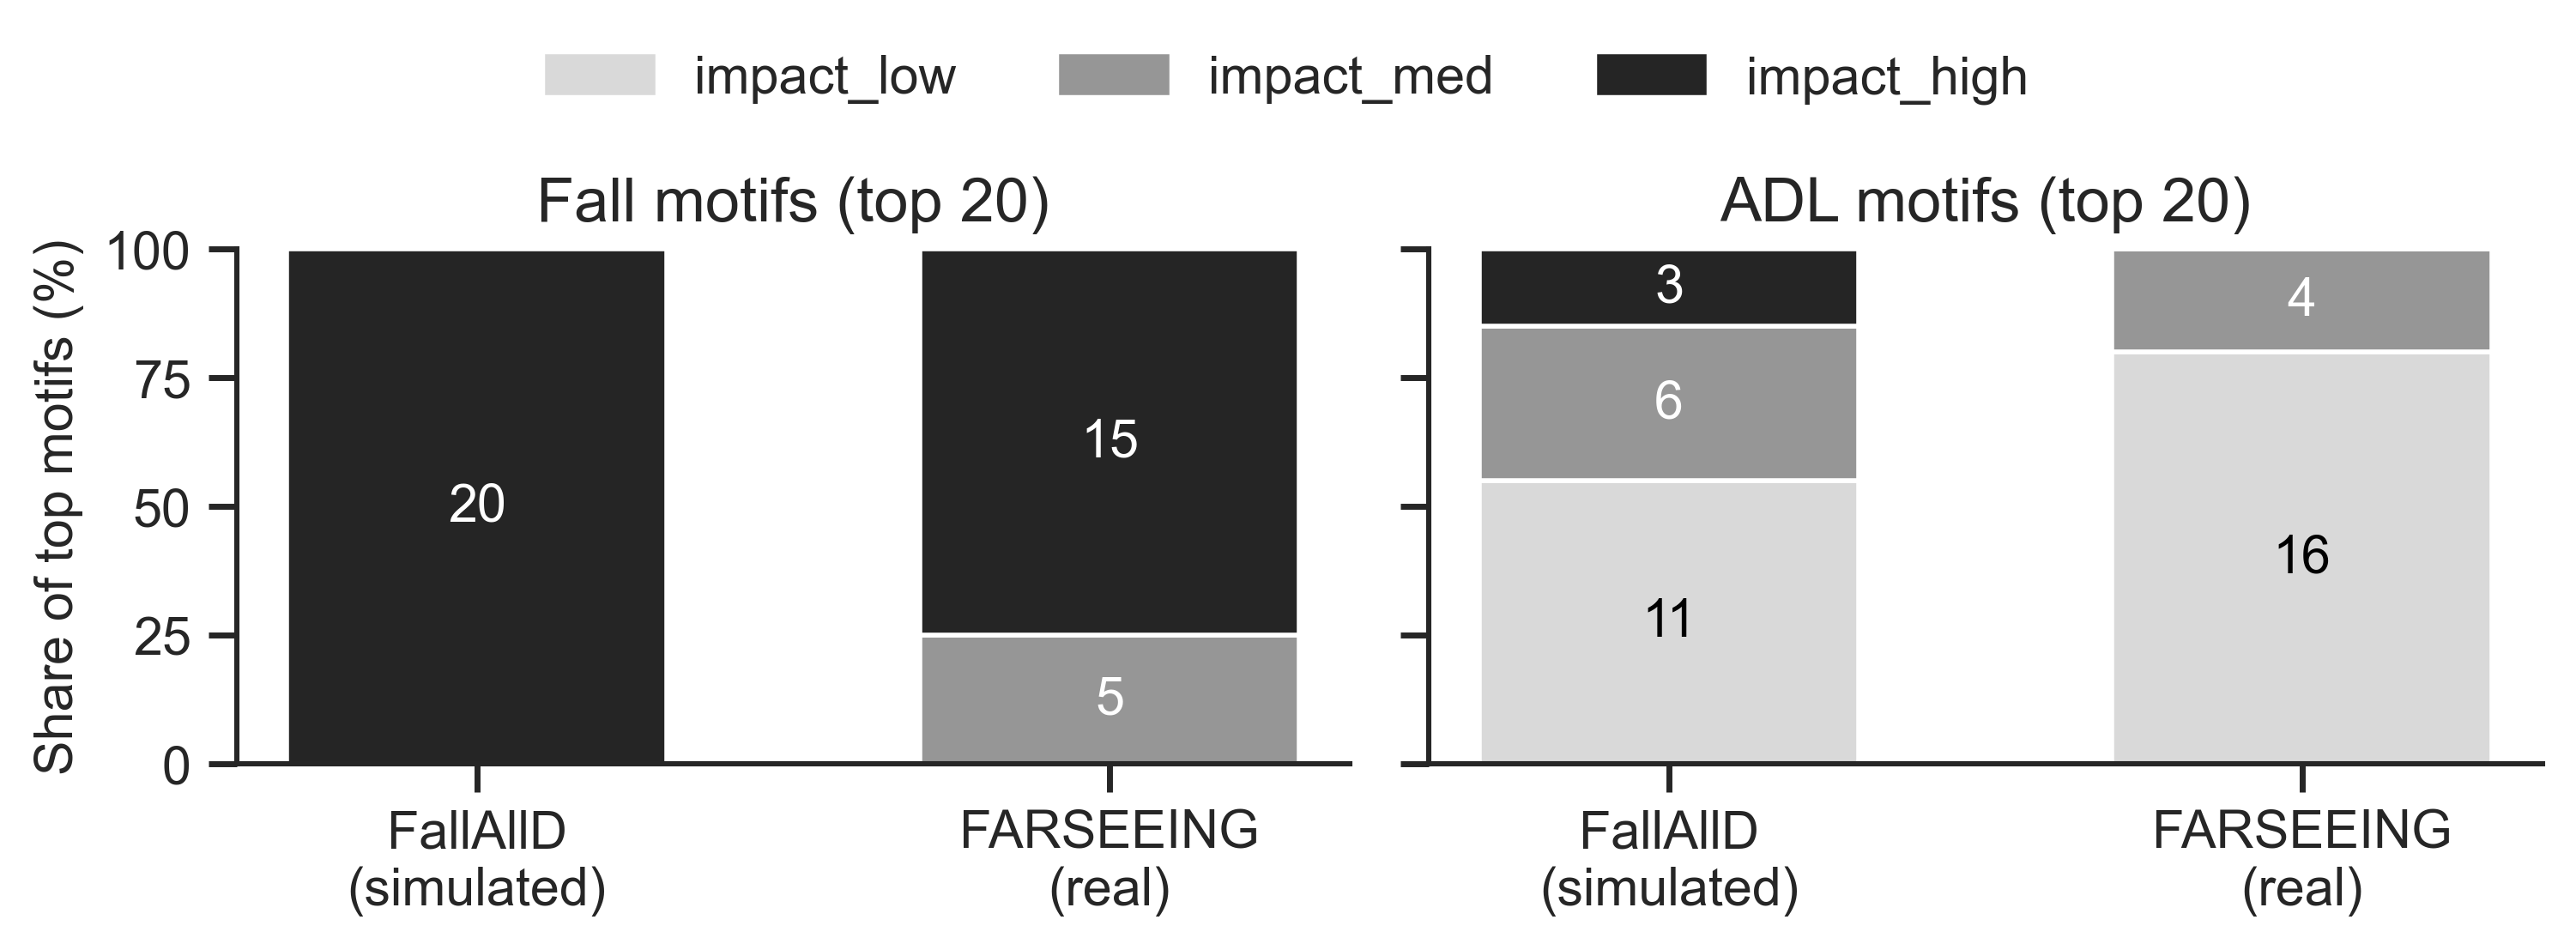

In [22]:
# 100% stacked composition of impact levels for top-20 motifs (Falls vs ADLs)
fall_motifs = pd.read_csv("output/tables/top_fall_motifs_by_dataset.csv")
adl_motifs = pd.read_csv("output/tables/top_normal_motifs_by_dataset.csv")

impact_levels = ["low", "med", "high"]
dataset_order = ["FallAllD", "FARSEEING"]

def impact_mix(df):
    top = (
        df.sort_values(["dataset", "abs_weight"], ascending=[True, False])
        .groupby("dataset", group_keys=False)
        .head(20)
        .copy()
    )
    top["impact_level"] = top["token"].str.extract(r"(?<!rel_)impact_(low|med|high)")

    counts = (
        top.groupby(["dataset", "impact_level"])
        .size()
        .unstack(fill_value=0)
        .reindex(index=dataset_order, columns=impact_levels, fill_value=0)
    )
    props = counts.div(counts.sum(axis=1), axis=0).fillna(0)
    return counts, props

fall_counts, fall_props = impact_mix(fall_motifs)
adl_counts, adl_props = impact_mix(adl_motifs)

fig, axes = plt.subplots(1, 2, figsize=(7.6, 2.45), sharey=True, dpi=400)
colors = {"low": "#d9d9d9", "med": "#969696", "high": "#252525"}

for ax, props, counts, title in [
    (axes[0], fall_props, fall_counts, "Fall motifs (top 20)"),
    (axes[1], adl_props, adl_counts, "ADL motifs (top 20)"),
]:
    x = np.arange(len(dataset_order))
    bottom = np.zeros(len(dataset_order))

    for level in impact_levels:
        vals = props[level].to_numpy() * 100
        cts = counts[level].to_numpy()
        ax.bar(x, vals, bottom=bottom, color=colors[level], width=0.60, label=f"impact_{level}")

        # Add in-bar labels as counts only since y-axis already encodes percentages.
        for i in range(len(x)):
            if vals[i] >= 8:
                y = bottom[i] + vals[i] / 2
                txt_color = "white" if level in {"med", "high"} else "black"
                ax.text(
                    x[i],
                    y,
                    f"{int(cts[i])}",
                    ha="center",
                    va="center",
                    fontsize=11,
                    color=txt_color,
                )
        bottom += vals

    ax.set_xticks(x)
    ax.set_xticklabels(["FallAllD\n(simulated)", "FARSEEING\n(real)"], fontsize=11)
    ax.set_ylim(0, 100)
    ax.set_title(title, fontsize=13)
    ax.tick_params(axis="y", labelsize=11)
    ax.grid(False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(1.1)
    ax.spines["bottom"].set_linewidth(1.1)

axes[0].set_ylabel("Share of top motifs (%)", fontsize=11)

handles = [plt.Rectangle((0, 0), 1, 1, color=colors[k]) for k in impact_levels]
labels = ["impact_low", "impact_med", "impact_high"]
fig.legend(handles, labels, frameon=False, ncol=3, loc="upper center", bbox_to_anchor=(0.5, 1.14), fontsize=11)

fig.tight_layout(pad=0.8)
os.makedirs("output/figures", exist_ok=True)
fig.savefig("output/figures/vocab_impact_distribution.pdf", dpi=400, bbox_inches="tight")

print("Fall impact counts (top-20):")
display(fall_counts)
print("ADL impact counts (top-20):")
display(adl_counts)
print("Saved: output/figures/vocab_impact_distribution.pdf")

In [23]:
# Top tokens appearing in both datasets
shared_fall_tokens = (
    set(fall_tokens_fallalld["token"])
    & set(fall_tokens_farseeing["token"])
)

shared_adl_tokens = (
    set(normal_tokens_fallalld["token"])
    & set(normal_tokens_farseeing["token"])
)

shared_fall_motifs = fall_motif_df[
    fall_motif_df["token"].isin(shared_fall_tokens)
].sort_values(["weight","token"], ascending=False).head(6)
shared_fall_motifs["type"] = "Fall"

shared_adl_motifs = normal_motif_df[
    normal_motif_df["token"].isin(shared_adl_tokens)
].sort_values(["weight","token"], ascending=True).head(6)
shared_adl_motifs["type"] = "ADL"
shared_motifs = pd.concat([shared_fall_motifs, shared_adl_motifs], ignore_index=True)
shared_motifs.to_csv("output/tables/shared_fall_motifs.csv", index=False)
print("\nShared Motifs Across Datasets")
display(shared_motifs)


Shared Motifs Across Datasets


,token,weight,abs_weight,dataset,type
0,d c impact_high rel_impact_high,2.620473,2.620473,FallAllD,Fall
1,d c impact_high rel_impact_high,2.604103,2.604103,FARSEEING,Fall
2,c d c impact_high rel_impact_high,1.938829,1.938829,FallAllD,Fall
3,c d c impact_high,1.938829,1.938829,FallAllD,Fall
4,b d c impact_high rel_impact_high,1.797452,1.797452,FARSEEING,Fall
5,b d c impact_high,1.797452,1.797452,FARSEEING,Fall
6,c c c impact_low,-2.436943,2.436943,FallAllD,ADL
7,c c c impact_low,-2.348510,2.348510,FARSEEING,ADL
8,c c c impact_med,-1.823184,1.823184,FallAllD,ADL
9,c c impact_low rel_impact_low,-1.761079,1.761079,FARSEEING,ADL


In [24]:
motifs_df_fall = utils.select_visualization_motifs(
    top_10_tokens.query('type=="Fall"'), n=1)
motifs_df_adl = utils.select_visualization_motifs(
    top_10_tokens.query('type=="ADL"'), n=1)
motifs_df = pd.concat([motifs_df_fall, motifs_df_adl], ignore_index=True)
display(motifs_df)

,token,weight,abs_weight,dataset,type,len
0,d c impact_high rel_impact_high,2.604103,2.604103,FARSEEING,Fall,4
1,c c c impact_low,-2.348510,2.348510,FARSEEING,ADL,4


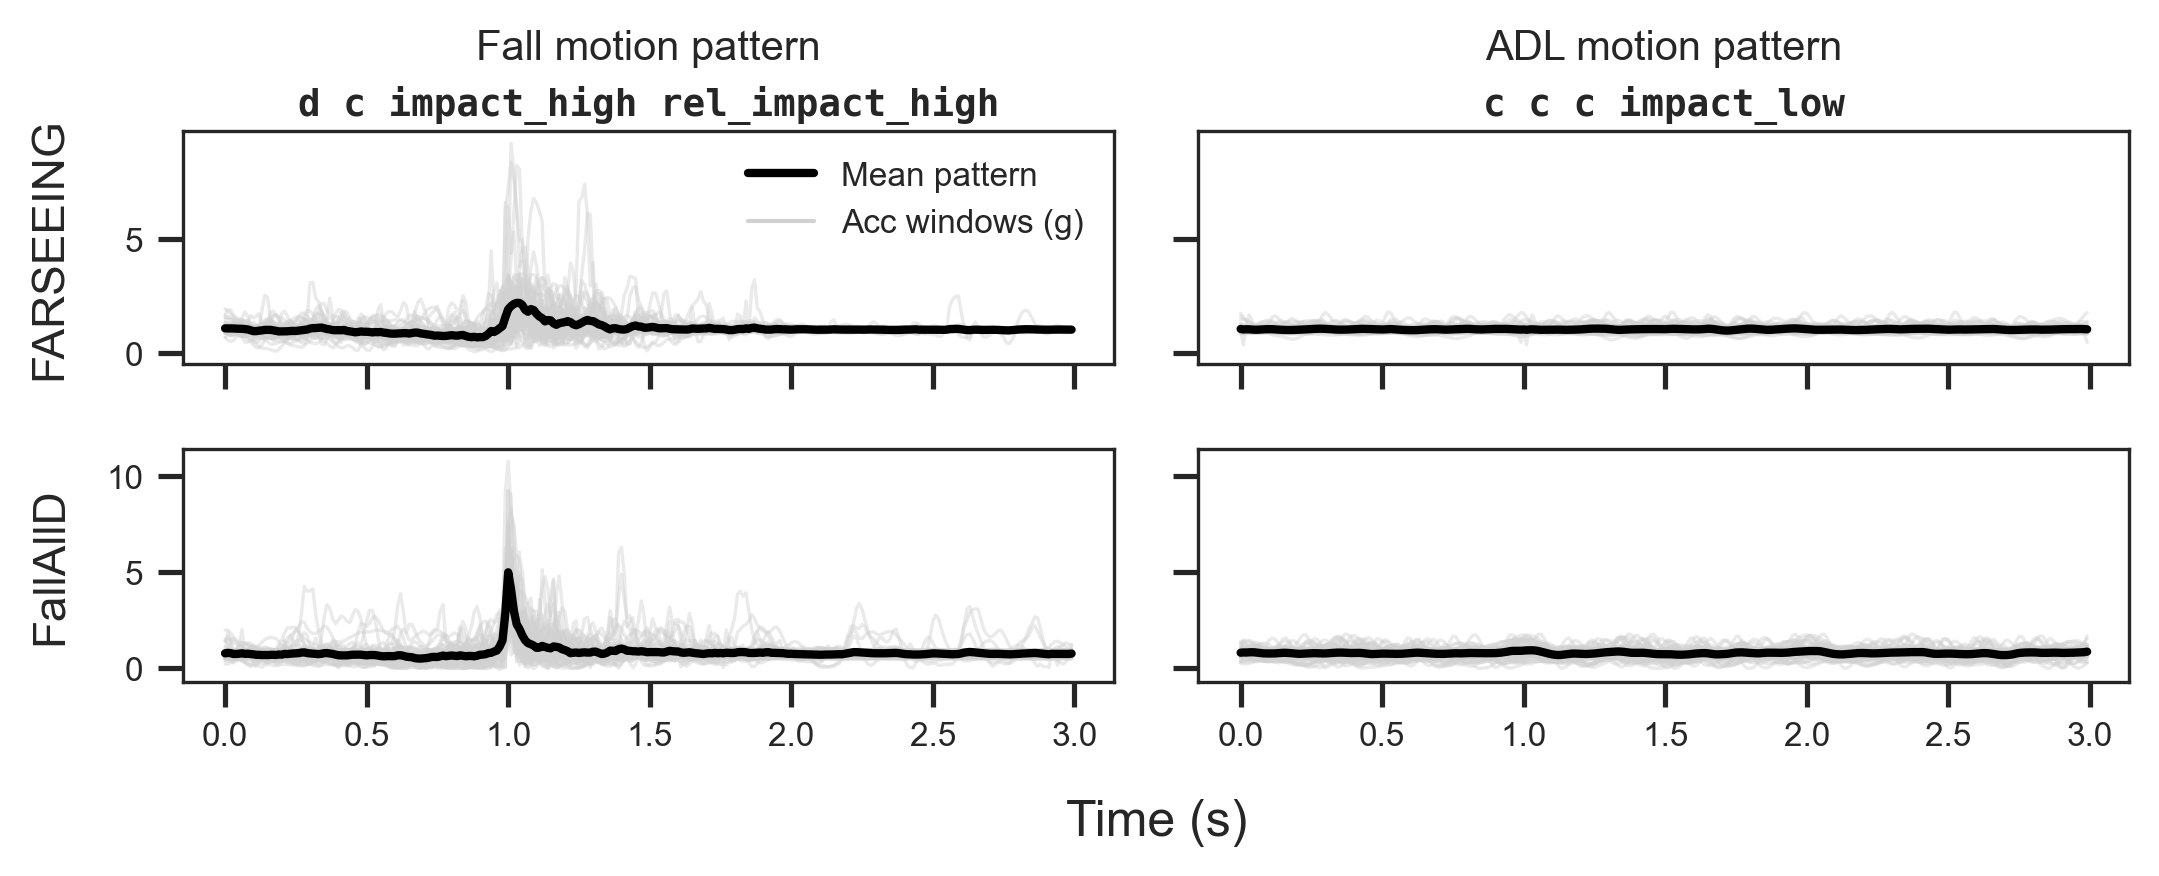

In [25]:
motif_axes = utils.plot_motif_grid(fallLM_farseeing, fallLM_fallalld, motifs_df, 
                    X_train, X_train_f, max_samples=50)
fig = np.ravel(motif_axes)[0].figure
fig.savefig("output/figures/motif_grid.pdf", dpi=300, bbox_inches="tight")

,token,type
0,d c impact_high rel_impact_high,Fall
1,b d c impact_med,Fall
2,b d c impact_high rel_impact_high,Fall
3,c c c impact_low,ADL
4,c c impact_low rel_impact_low,ADL
5,c c impact_low rel_impact_med,ADL


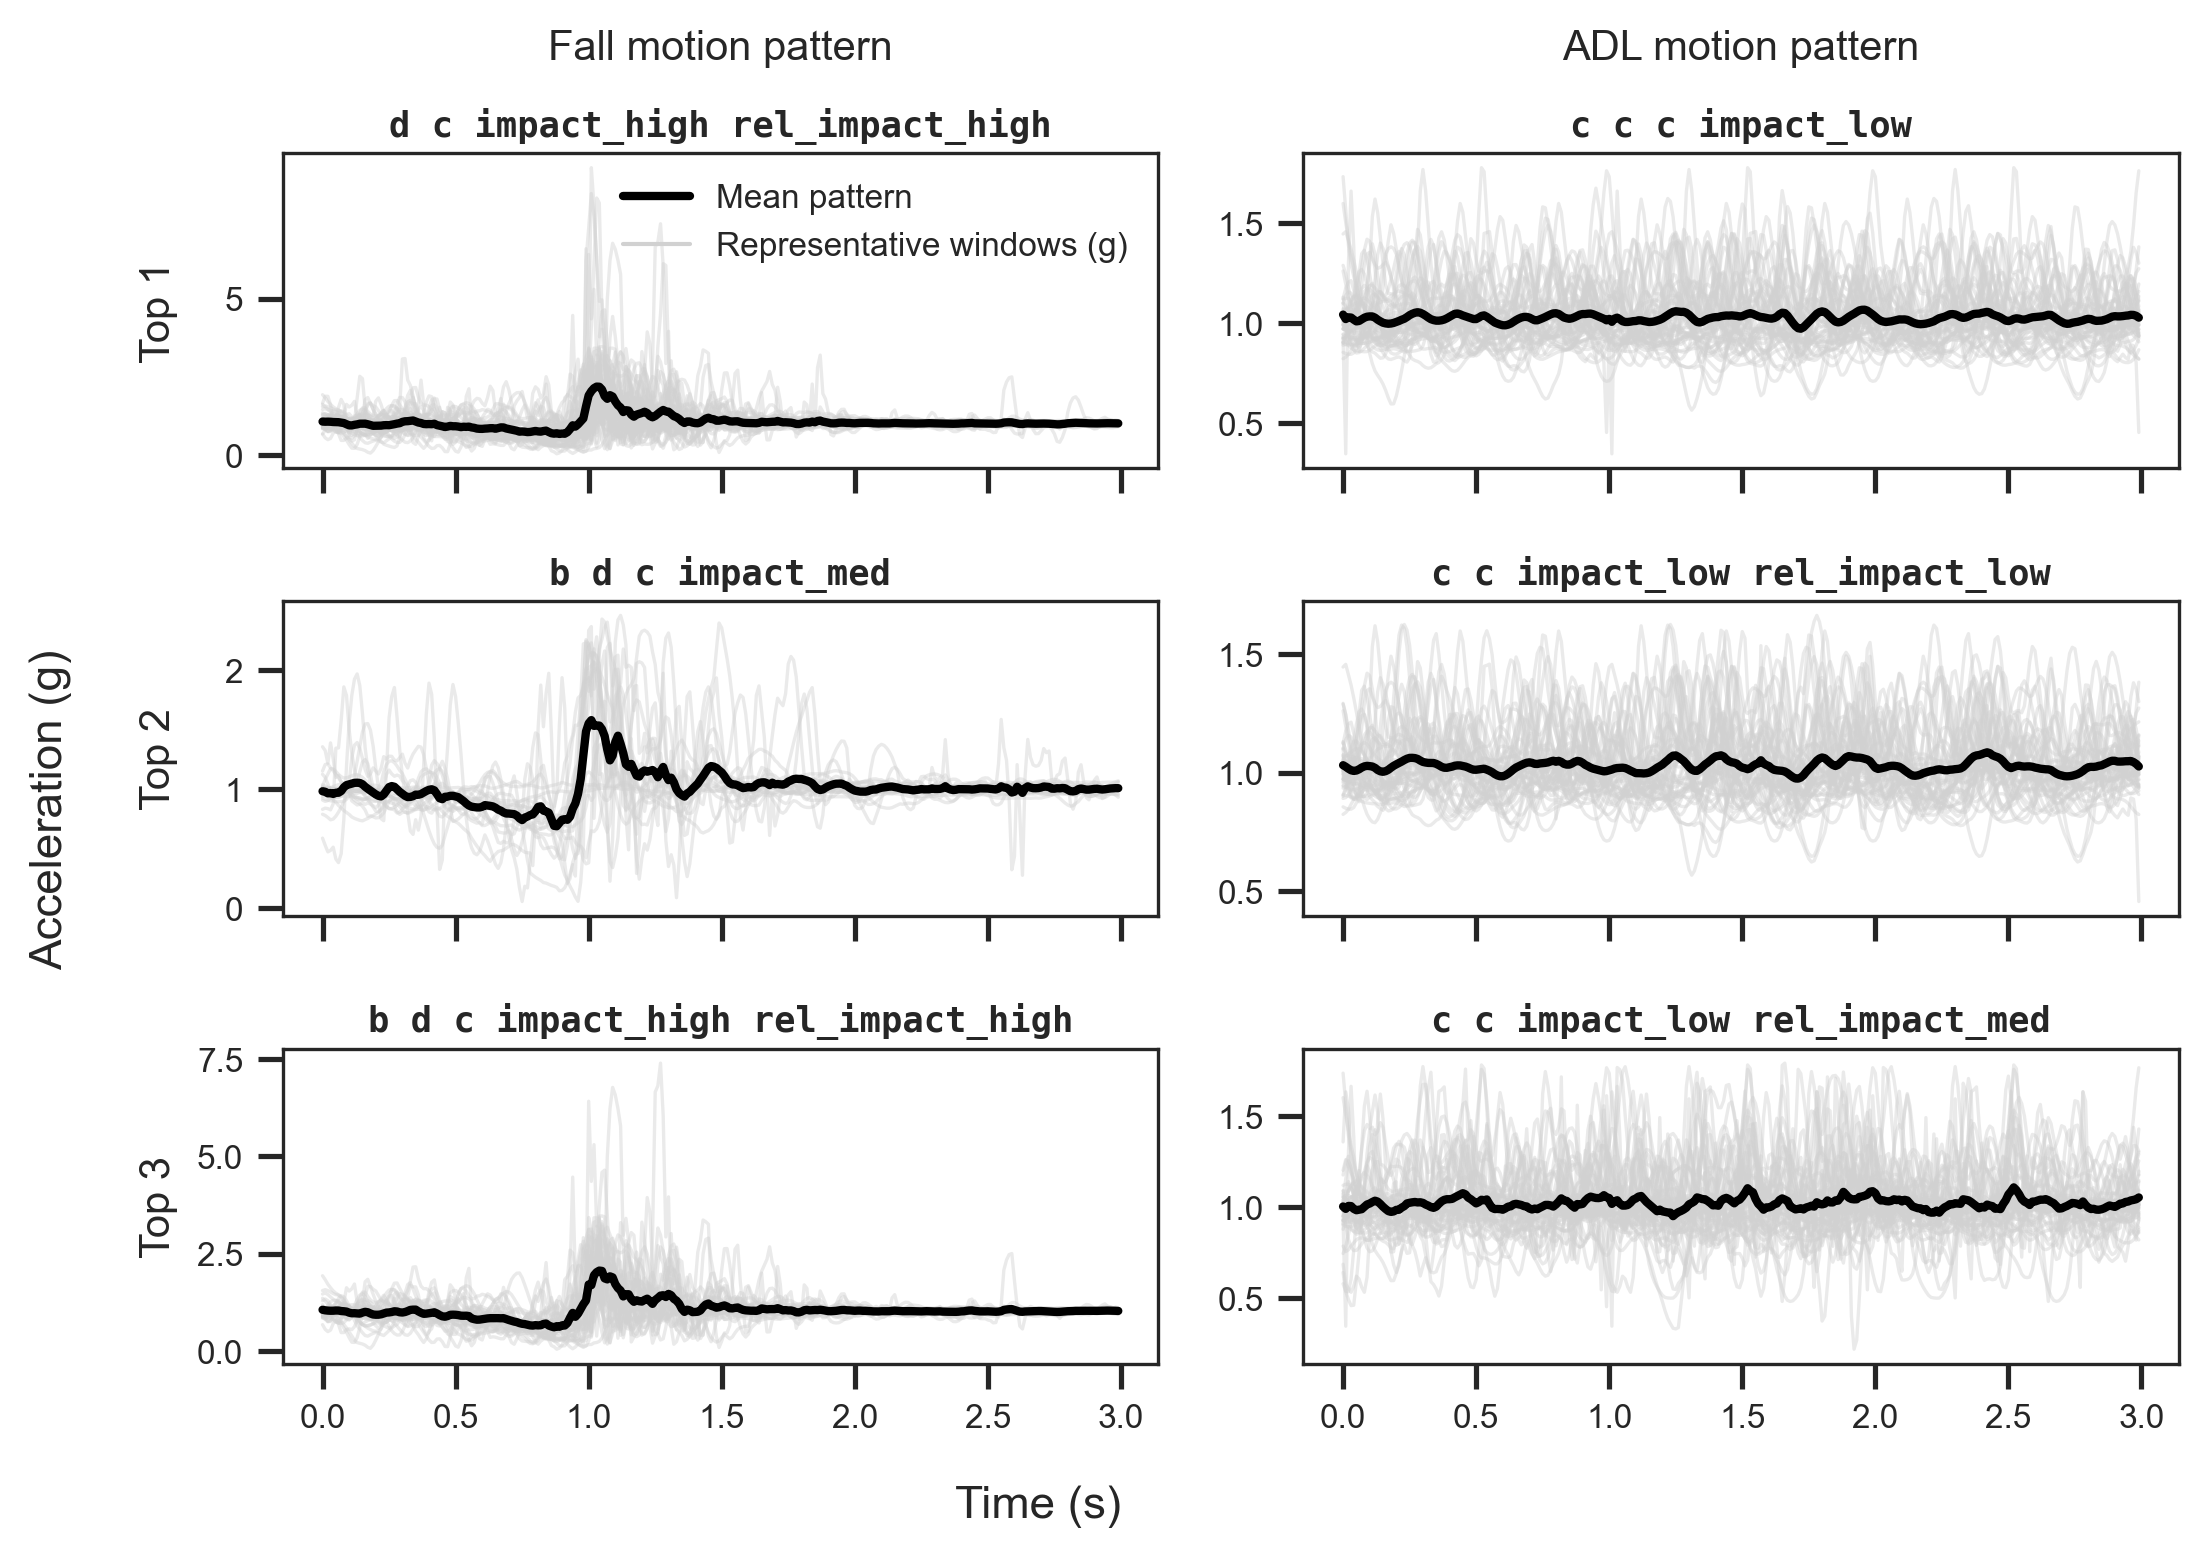

In [31]:
# Top 3 FARSEEING fall + ADL motifs (min 4-gram, ranked by abs_weight)
fall_top3 = (
    fall_tokens_farseeing[fall_tokens_farseeing["token"].str.split().str.len() >= 4]
    .head(3).copy()
)
fall_top3["type"] = "Fall"

adl_top3 = (
    normal_tokens_farseeing[normal_tokens_farseeing["token"].str.split().str.len() >= 4]
    .head(3).copy()
)
adl_top3["type"] = "ADL"

motif_df_topn = pd.concat([fall_top3, adl_top3], ignore_index=True)
display(motif_df_topn[["token", "type"]])

axes = utils.plot_motif_grid_topn(fallLM_farseeing, motif_df_topn, X_train, n=3, max_samples=50)
fig = np.ravel(axes)[0].figure
fig.savefig("output/figures/motif_grid_topn.pdf", dpi=300, bbox_inches="tight")

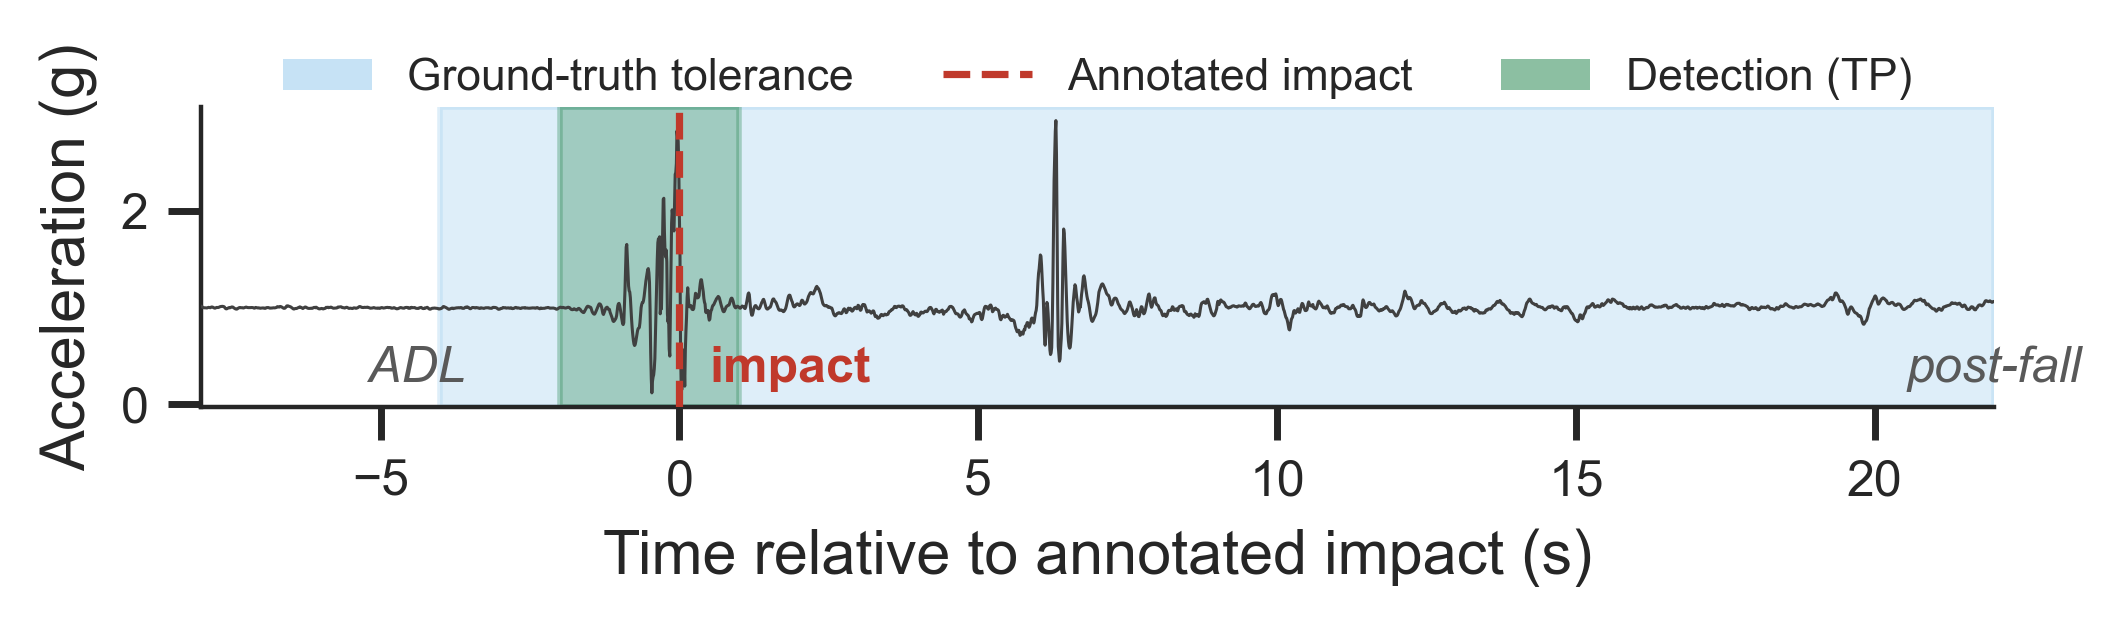

Recording 0: event @600s | window [-8s, +22s] | debounced alarms=1 (TP=1 FP=0) | GT range [-4, 22]s | post='post-fall'


In [30]:
from src.costream.evaluation.event_detection import get_high_confidence_regions
from src.fall_showcase import plot_fall_showcase
diag = plot_fall_showcase(test_signals, test_events, fallLM_farseeing,
                          get_high_confidence_regions,
                          save_path="output/figures/fall_event_showcase.pdf")